Bibliotecas

In [35]:
import tkinter as tk
from tkinter import filedialog
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

Convolução 1D

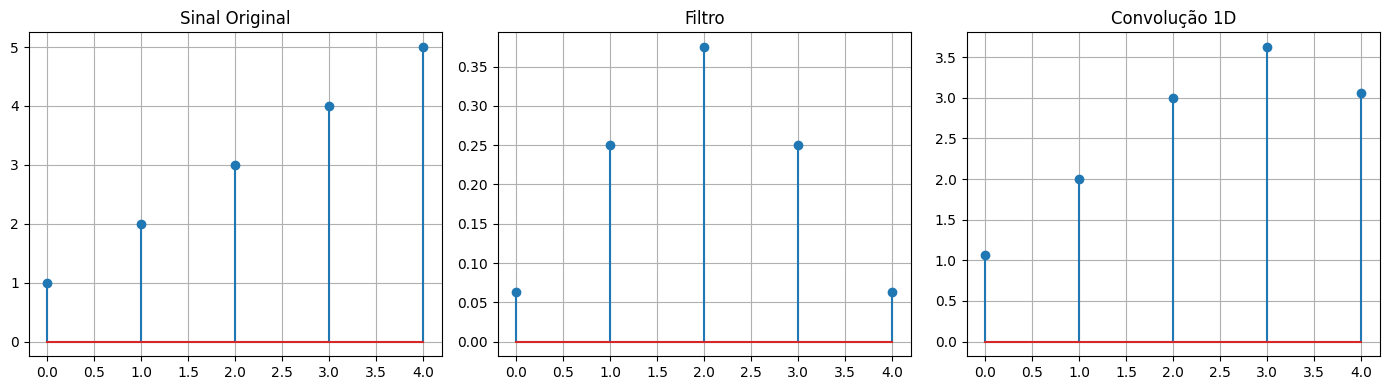

In [36]:
# Filtro Gaussiano 1D (suavização) : Dá mais peso aos valores centrais do sinal, suavizando as variações bruscas.
filtro = np.array([1, 4, 6, 4, 1]) / 16

sinal = np.array([1, 2, 3, 4, 5])

conv1d = np.convolve(sinal, filtro, mode='same')

# Plotagem dos resultados
fig, ax = plt.subplots(1, 3, figsize=(14, 4), sharex=True)

# Sinal orignal
ax[0].stem(sinal)
ax[0].set_title('Sinal Original')
ax[0].grid()

# Filtro
ax[1].stem(filtro)
ax[1].set_title('Filtro')
ax[1].grid()

# Convolução
ax[2].stem(conv1d)
ax[2].set_title('Convolução 1D')
ax[2].grid()


plt.tight_layout()
plt.show()

Convolução 2D

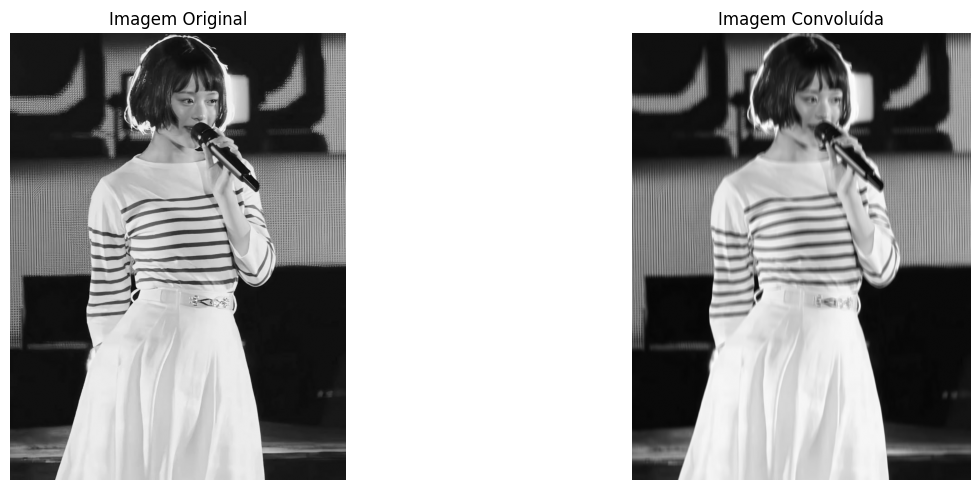

In [37]:
def carregar_imagem():
    root = tk.Tk() # Inicia o motor gráfico do Tkinter
    root.withdraw() # Esconde a janela
    root.attributes("-topmost", True) # Garante que a janela de diálogo fique em primeiro plano
    caminho_da_imagem = filedialog.askopenfilename(
        title="Selecione uma imagem", filetypes=[("Image files", "*.jpg;*.jpeg;*.png;*.bmp")]
        ) # Guarda o caminho da imagem que voce selecionou

    if caminho_da_imagem:
        img_gray = Image.open(caminho_da_imagem).convert('L') # Abre a imagem e converte para escala de cinza
        img_matriz = np.array(img_gray) # Converte a imagem para uma matriz NumPy
        return img_matriz
    
    return "Nenhuma imagem selecionada."

def convolve_linha(img, filtro):
    h, w = img.shape # Pegamos as dimensões da imagem
    out_w = w - len(filtro) + 1 # Calculamos a largura da imagem convoluída
    img_conv = np.zeros((h, out_w)) # Criamos uma matriz para armazenar a imagem convoluída

    for i in range(h): # Para cada linha da imagem
        img_conv[i, :] = np.convolve(img[i, :], filtro, mode='valid') # Convoluímos a linha com o filtro e armazenamos o resultado

    return img_conv

filtro = np.ones(9) / 9 
img_matriz = carregar_imagem()
img_linhas = convolve_linha(img_matriz, filtro)
img_conv = convolve_linha(img_matriz.T, filtro).T # Convolução nas colunas (transposta para aplicar o filtro nas colunas)

# Plotagem dos resultados
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].imshow(img_matriz, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Imagem Original')

ax[1].imshow(img_conv, cmap='gray')
ax[1].axis('off')
ax[1].set_title('Imagem Convoluída')

plt.tight_layout()
plt.show()